In [1]:
"""
Simple T-Test Analysis for SPAD Data and ROC/AUC Evaluation
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,
})

T-Test Analysis at 14.00h

DSS Feces vs Healthy Feces
  332.3±98.7 vs 237.7±50.0
  p=0.4403 ns

0mM Control vs Healthy Feces
  265.3±84.0 vs 237.7±50.0
  p=0.7911 ns

0mM Control vs DSS Feces
  265.3±84.0 vs 332.3±98.7
  p=0.6324 ns


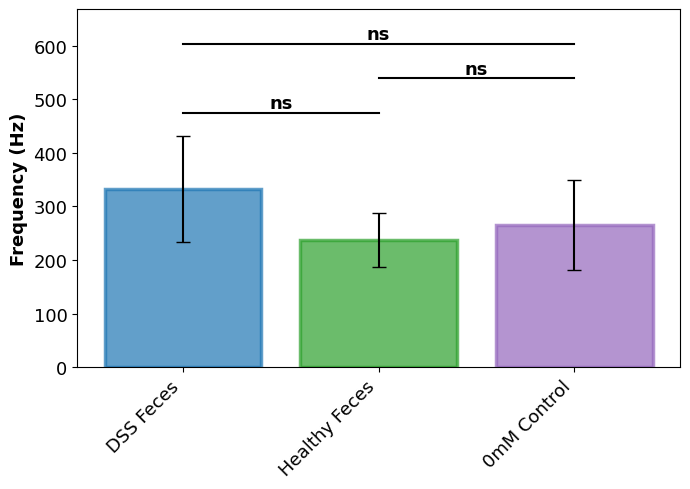


✅ Done! (*** p<0.001, ** p<0.01, * p<0.05, ns p≥0.05)


In [2]:
csv_file = "SPAD\lactate_SPAD_stats.csv"
time_point_hours = 14 #choosen separetely for each biosensor
# #HEME
# compare_pairs = [
#     ("0uM Control", "12.5uM Control"),
#     ("DSS Feces", "Healthy Feces"),
#     ("12.5uM Control", "DSS Feces"),
#     ("12.5uM Control", "Healthy Feces"),
#     ("0uM Control", "DSS Feces"),
#     ("0uM Control", "Healthy Feces"),
# ]
#BUTYRATE
# compare_pairs = [
#     ("0mM Control", "50mM Control"),
#     ("DSS Feces", "Healthy Feces"),
#     ("50mM Control", "DSS Feces"),
#     ("50mM Control", "Healthy Feces"),
#     ("0mM Control", "DSS Feces"),
#     ("0mM Control", "Healthy Feces"),
# ]
#LACTATE
# compare_pairs = [
#     ("0mM Control", "200mM Control"),
#     ("DSS Feces + 200mM", "Healthy Feces"),
#     ("200mM Control", "DSS Feces + 200mM"),
#     ("200mM Control", "Healthy Feces"),
#     ("0mM Control", "DSS Feces + 200mM"),
#     ("0mM Control", "Healthy Feces"),
# ]
compare_pairs = [("DSS Feces", "Healthy Feces"),("0mM Control", "Healthy Feces"),("0mM Control", "DSS Feces")]
# Load data
df = pd.read_csv(csv_file)
time_idx = np.argmin(np.abs(df['Time_hours'] - time_point_hours))
actual_time = df['Time_hours'].iloc[time_idx]

print(f"T-Test Analysis at {actual_time:.2f}h")
print("=" * 60)

results = []
for g1, g2 in compare_pairs:
    # Get replicate data
    d1 = df.loc[time_idx, [c for c in df.columns if c.startswith(f"{g1}_Rep")]].values
    d2 = df.loc[time_idx, [c for c in df.columns if c.startswith(f"{g2}_Rep")]].values

    # T-test
    t, p = stats.ttest_ind(d1, d2)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"

    print(f"\n{g1} vs {g2}")
    print(f"  {np.mean(d1):.1f}±{stats.sem(d1):.1f} vs {np.mean(d2):.1f}±{stats.sem(d2):.1f}")
    print(f"  p={p:.4f} {sig}")

    results.append([g1, d1, g2, d2, p, sig])
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 5))   #(5,7)
groups = []
means = []
sems = []

for g1, d1, g2, d2, p, sig in results:
    if g1 not in groups:
        groups.append(g1)
        means.append(np.mean(d1))
        sems.append(stats.sem(d1))
    if g2 not in groups:
        groups.append(g2)
        means.append(np.mean(d2))
        sems.append(stats.sem(d2))

x = np.arange(len(groups))
colors = ['#1f77b4',
          # '#ff7f0e',
          # '#d62728',
          '#2ca02c',
          '#9467bd',
          '#8c564b']
bars = ax.bar(x, means, yerr=sems, capsize=5, alpha=0.7, edgecolor='black', linewidth=2.5)
for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

y_max = max(means) + max(sems)
y_offset = y_max * 0.1
for g1, d1, g2, d2, p, sig in results:
    x1, x2 = groups.index(g1), groups.index(g2)
    y = y_max + y_offset
    ax.plot([x1, x2], [y, y], 'k-', lw=1.5)
    ax.text((x1+x2)/2, y+y_offset*0.2, sig, ha='center', fontsize=13, fontweight='bold')
    y_max = y + y_offset*0.5

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=45, ha='right')
ax.set_ylabel('Frequency (Hz)', fontsize=13, fontweight='bold')
ax.set_ylim(0, y_max + y_offset)
ax.tick_params(axis='both', labelsize=13)
plt.tight_layout()
# plt.savefig(f'ttest_{actual_time:.0f}h.png', dpi=600, bbox_inches='tight')
plt.show()



In [3]:
from sklearn.metrics import roc_auc_score

for g1, d1, g2, d2, p, sig in results:
    y_true = [1]*len(d1) + [0]*len(d2)
    y_scores = list(d1) + list(d2)
    auc = roc_auc_score(y_true, y_scores) if len(set(y_scores))>1 else 0.5
    print(f"{g1} vs {g2}: AUC = {auc:.3f}")

DSS Feces vs Healthy Feces: AUC = 0.667
0mM Control vs Healthy Feces: AUC = 0.556
0mM Control vs DSS Feces: AUC = 0.222


In [4]:
df = df.sort_values('Time_hours').reset_index(drop=True)
rep_cols = [c for c in df.columns if 'Rep' in c]
df[rep_cols] = df[rep_cols].rolling(window=300, center=True, min_periods=1).mean()
g1 = "DSS Feces"    # "DSS Feces"
g2 = "Healthy Feces"
g1_cols = [c for c in df.columns if c.startswith(f"{g1}_Rep")]
g2_cols = [c for c in df.columns if c.startswith(f"{g2}_Rep")]
auc_records,roc_records = [],[]
for idx, row in tqdm(df.iterrows(), desc="processing data"):
    t_hours = row['Time_hours']
    d1 = row[g1_cols].dropna().values
    d2 = row[g2_cols].dropna().values
    if len(d1) == 0 or len(d2) == 0:
        continue

    y_true = [1]*len(d1) + [0]*len(d2)
    y_scores = list(d1) + list(d2)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    try:
        auc = roc_auc_score(y_true, y_scores) if len(set(y_scores)) > 1 else 0.5
    except ValueError:
        auc = 0.5
    auc_records.append({'Time_hours': t_hours, 'AUC': auc})

    for f, p in zip(fpr, tpr):
        roc_records.append({'Time_hours': t_hours, 'FPR': f, 'TPR': p})
df_auc = pd.DataFrame(auc_records)
df_roc = pd.DataFrame(roc_records)

processing data: 0it [00:00, ?it/s]

In [5]:
df_auc.head()

,Time_hours,AUC
0,0.000000,0.111111
1,0.000278,0.111111
2,0.000556,0.111111
3,0.000833,0.111111
4,0.001111,0.111111


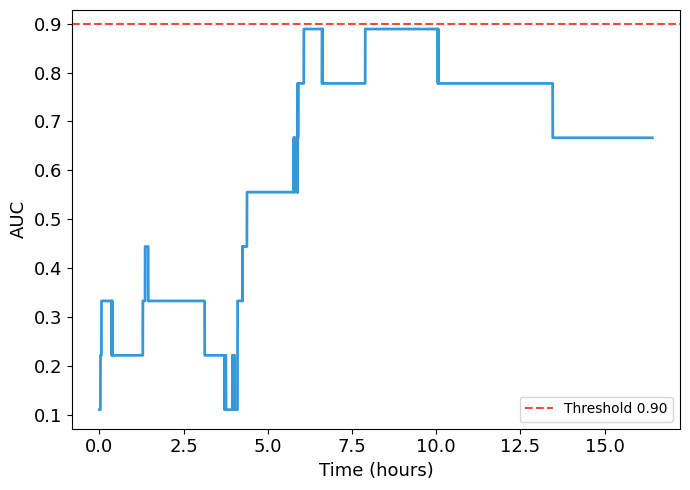

In [6]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_auc['Time_hours'], df_auc['AUC'], color='#3498db', lw=2)
ax.axhline(0.90, color='#e74c3c', linestyle='--', label='Threshold 0.90')
ax.set_xlabel('Time (hours)',fontsize = 13)
ax.set_ylabel('AUC',fontsize = 13)
ax.tick_params(axis='both', labelsize=13)
# plt.title(f'AUC Dynamics: {g1} vs {g2}')
plt.tight_layout()
# plt.savefig(f'auc_over_time_{g1}_vs_{g2}_lactate.png', dpi=600, bbox_inches='tight')
plt.legend()
plt.show()

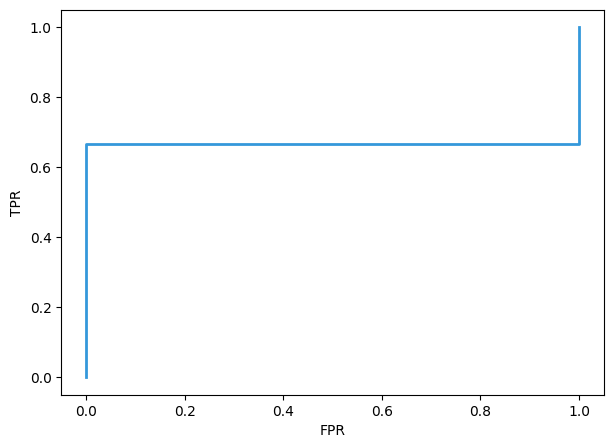

In [7]:
%matplotlib inline
timepoint = df_roc[df_roc['Time_hours']==14]
plt.figure(figsize=(7, 5))
plt.plot(timepoint['FPR'], timepoint['TPR'], color='#3498db', lw=2)
# plt.axhline(0.90, color='#e74c3c', linestyle='--', label='Threshold 0.90')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

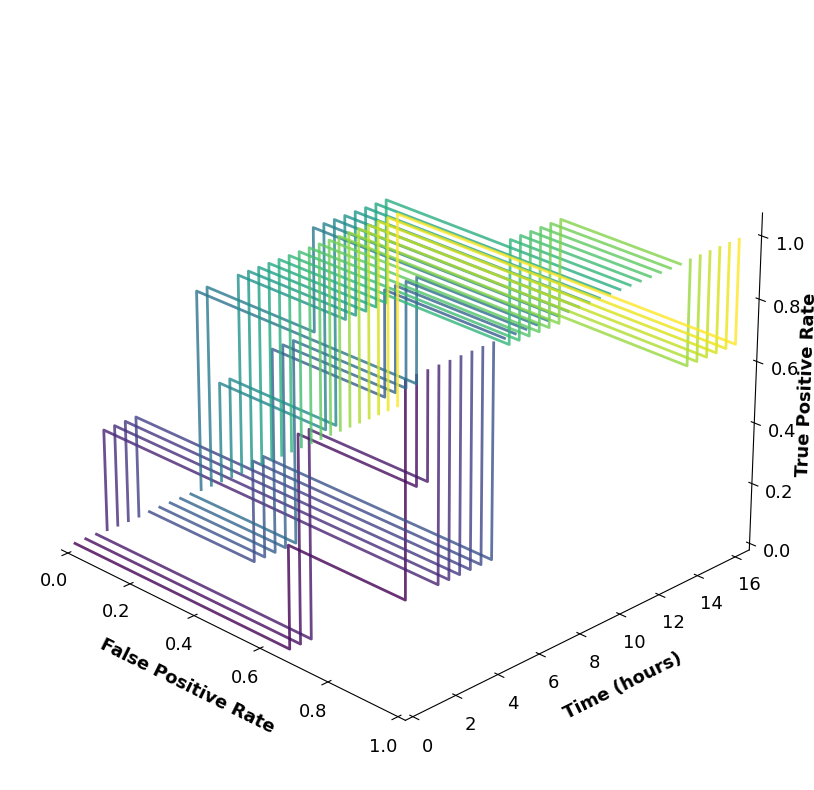

In [8]:
%matplotlib inline
import matplotlib.cm as cm

auc_threshold = 0.90
diag_time = None

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
time_step_hours = 0.5 #check each half an hour
time_slices = np.arange(df['Time_hours'].min(), df['Time_hours'].max(), time_step_hours)
colors = cm.viridis(np.linspace(0, 1, len(time_slices)))
#find the earliest time point where AUC exceeds the threshold
for idx, row in df.iterrows():
    actual_t = row['Time_hours']
    d1 = row[g1_cols].dropna().values
    d2 = row[g2_cols].dropna().values

    if len(d1) == 0 or len(d2) == 0:
        continue

    y_true = [1]*len(d1) + [0]*len(d2)
    y_scores = list(d1) + list(d2)

    try:
        auc = roc_auc_score(y_true, y_scores) if len(set(y_scores)) > 1 else 0.5
    except ValueError:
        auc = 0.5

    if auc >= auc_threshold and diag_time is None:
        diag_time = actual_t
        break


for i, target_t in enumerate(time_slices):
    idx = (df['Time_hours'] - target_t).abs().argmin()
    row = df.iloc[idx]
    actual_t = row['Time_hours']

    d1 = row[g1_cols].dropna().values
    d2 = row[g2_cols].dropna().values

    if len(d1) == 0 or len(d2) == 0:
        continue

    y_true = [1]*len(d1) + [0]*len(d2)
    y_scores = list(d1) + list(d2)

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    ax.plot(fpr, tpr, zs=actual_t, zdir='y', color=colors[i], lw=2, alpha=0.8)

if diag_time is not None:
    xx, zz = np.meshgrid([0, 1], [0, 1])
    yy = np.full_like(xx, diag_time)
    ax.plot_surface(xx, yy, zz, color='grey', alpha=0.20, edgecolor='none')
    # ax.text(0.5, diag_time, 1.1, f"Ready: {diag_time:.1f}h",
    #         color='grey', fontweight='bold', ha='center', va='bottom')


ax.set_xlabel('False Positive Rate', fontweight='bold', labelpad=10,fontsize=13)
ax.set_ylabel('Time (hours)', fontweight='bold', labelpad=10,fontsize=13)
ax.set_zlabel('True Positive Rate', fontweight='bold', labelpad=0,fontsize=13)
ax.tick_params(axis='both', labelsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([df['Time_hours'].min(), df['Time_hours'].max()])
ax.set_zlim([0, 1.05])

ax.view_init(elev=25, azim=-45)
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
plt.tight_layout()
# plt.savefig(f'roc_3d_{g1}_vs_{g2}_lactate.png', dpi=600, bbox_inches='tight')
plt.show()

In [9]:
diag_time